# Домашнє завдання

Ну що, налаштувалися на виконання нового завдання? Тодi полетiли!

Сьогодні ви використаєте метрики відстані для обчислення матриці відстані та застосування кластеризації даних, а також коефіцієнти кореляції для пошуку зв'язків між ознаками

Це допоможе вам закрiпити наступні навички:  

- Норми, метрики, використання для опису даних.
- Застосування функції Panda, Numpy.

##Завдання (крок за кроком)

**1. Завантажте та ознайомтесь з даними:**

- Завантажте набір даних Breast Cancer за допомогою функції `load_breast_cancer()` з бібліотеки `sklearn`.
- Перегляньте опис набору даних, щоб зрозуміти структуру та характеристики.

**2. Створіть DataFrame:**

- Створіть DataFrame, використовуючи дані з набору Breast Cancer.

**3. Виведіть інформацію про дані:**

- Використовуйте функцію `info()` для виведення інформації про типи стовпців та кількість непустих значень в кожному стовпці.

**4. Виведіть описові статистики:**

- Використовуйте функцію `describe()` для виведення описових статистик даних.

**5. Стандартизуйте дані:**

- Застосуйте процес стандартизації даних за допомогою функцій з конспекту або бібліотеки `sklearn`.

**6. Побудуйте точкові діаграми:**

- Використайте функцію `pairplot()` з бібліотеки `seaborn` для побудови точкових діаграм між усіма стовпцями.

**7. Обчисліть матриці відстаней:**

- Використовуйте алгоритми та функції з конспекту для обчислення матриці відстаней для різних метрик: cityblock, cosine, euclidean, l1, manhattan.

**8. Візуалізуйте отримані матриці:**

- Використайте функцію `heatmap` з бібліотеки `seaborn` або інші методи візуалізації для представлення отриманих матриць відстаней.

**9. Зробіть висновок:**

- Зробіть висновок на основі аналізу отриманих результатів та порівняйте ефективність різних метрик відстаней для даного набору даних.

##Пiдказки

Для виконання завдання використовуй функції numpy, та алгоритми з конспекту до цієї теми.

##Формат здачі

1. Завантажте блокнот Google Colab у форматі IPYNB на свій комп’ютер та прикріпіть його у LMS.

2. Прикріпіть посилання на ваш Colab у LMS, відправте на перевірку.

##Критерії прийому

- Усі вказані етапи виконані та проведені обчислювальні експерименти з різними ступенями стискання.
- До Colab додані висновки.

##Формат оцінювання

Оцiнка вiд 0 до 100

##Приклад

17 types of similarity and dissimilarity measures used in data science

https://towardsdatascience.com/17-types-of-similarity-and-dissimilarity-measures-used-in-data-science-3eb914d2681/

Генерація синтетичних даних

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import pairwise_distances, adjusted_rand_score
from sklearn.cluster import AgglomerativeClustering

def generate_manhattan_clusters(n_samples=150, dim=20, shift=10.0):
    assert n_samples % 2 == 0
    half = n_samples // 2

    base = np.random.normal(loc=0, scale=1.0, size=(half, dim))
    shifted = base.copy()
    shifted[:, 0] += shift  # зсув лише по осі F0

    X = np.vstack([base, shifted])
    y = np.array([0]*half + [1]*half)
    return X, y

X, y = generate_manhattan_clusters(n_samples=150, dim=20, shift=10.0)

df = pd.DataFrame(X, columns=[f'F{i}' for i in range(X.shape[1])])
df['Target'] = y



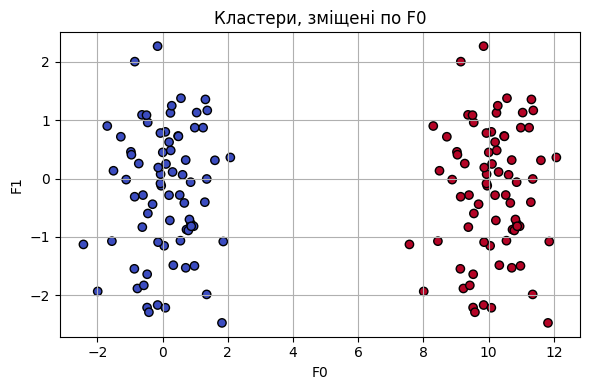

In [ ]:
plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k')
plt.title('Кластери, зміщені по F0')
plt.xlabel('F0')
plt.ylabel('F1')
plt.grid(True)
plt.tight_layout()
plt.show()


Побудова теплових карт різних відстаней

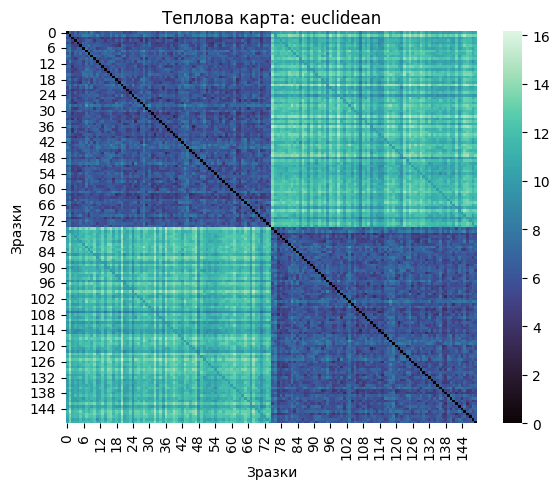

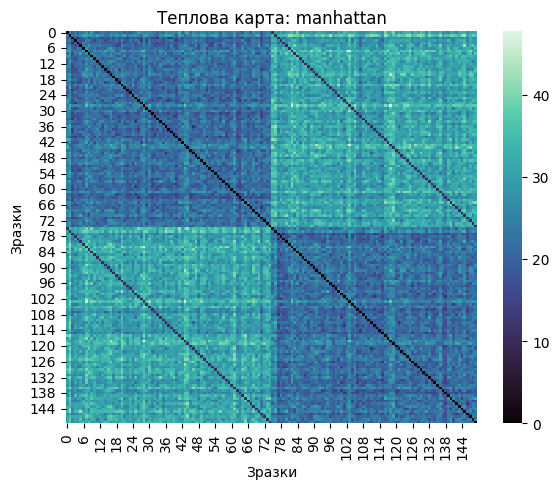

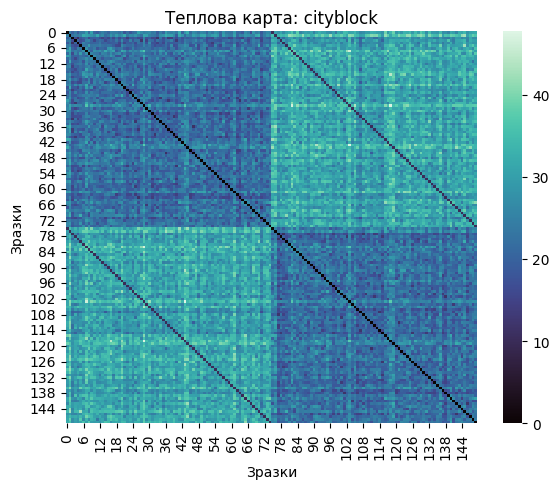

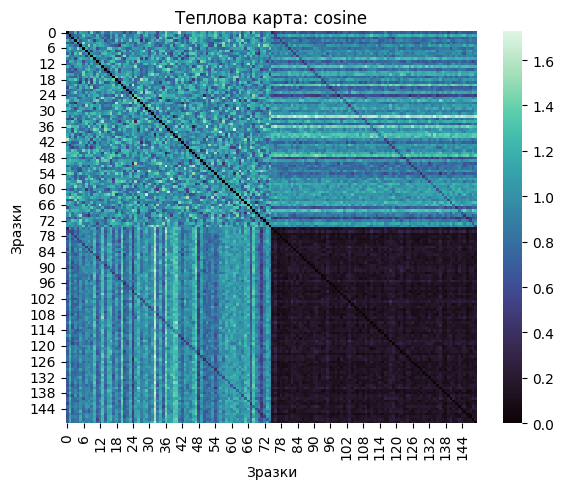

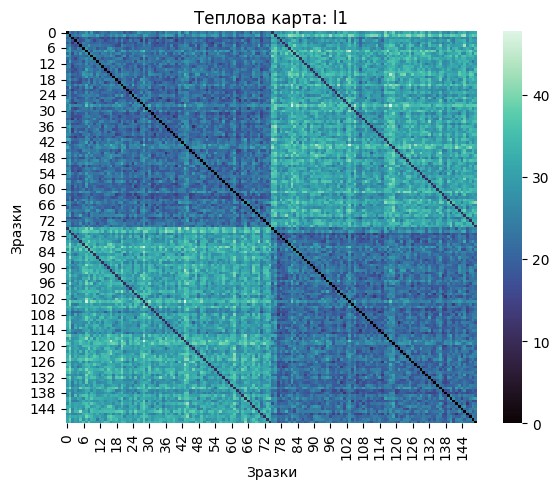

In [ ]:
def plot_distance_heatmap(data, metric):
    dist = pairwise_distances(data, metric=metric)
    plt.figure(figsize=(6, 5))
    sns.heatmap(dist, cmap='mako')
    plt.title(f'Теплова карта: {metric}')
    plt.xlabel('Зразки')
    plt.ylabel('Зразки')
    plt.tight_layout()
    plt.show()


metrics = ['euclidean', 'manhattan', 'cityblock', 'cosine', 'l1']
sample_data = df.drop('Target', axis=1)

for metric in metrics:
    plot_distance_heatmap(sample_data, metric)



Кластеризація для перевірки, які метрики краще описують дані

🔎 ARI для кожної метрики:
euclidean  ARI = 1.000
manhattan  ARI = -0.000
cityblock  ARI = -0.000
cosine     ARI = 0.099
l1         ARI = -0.000


/tmp/ipython-input-4009140034.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(ari_scores.keys()), y=list(ari_scores.values()), palette='viridis')


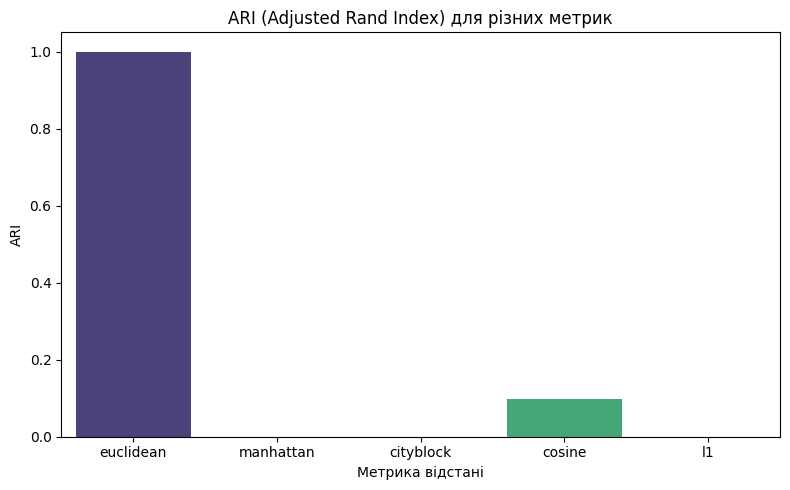

In [ ]:


true_labels = df['Target'].values
ari_scores = {}

print("🔎 ARI для кожної метрики:")
for metric in metrics:
    dist = pairwise_distances(sample_data, metric=metric)
    model = AgglomerativeClustering(n_clusters=2, metric='precomputed', linkage='average')
    pred_labels = model.fit_predict(dist)
    ari = adjusted_rand_score(true_labels, pred_labels)
    ari_scores[metric] = ari
    print(f"{metric:<10} ARI = {ari:.3f}")

plt.figure(figsize=(8, 5))
sns.barplot(x=list(ari_scores.keys()), y=list(ari_scores.values()), palette='viridis')
plt.title("ARI (Adjusted Rand Index) для різних метрик")
plt.xlabel("Метрика відстані")
plt.ylabel("ARI")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()



## Домашнє завдання: метрики відстані на наборі даних Breast Cancer

### 1. Завантаження та ознайомлення з даними

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

breast_cancer = load_breast_cancer()
print(breast_cancer.DESCR[:1400])
print("...")
print("\nКласи:", list(breast_cancer.target_names))
print("Кількість ознак:", len(breast_cancer.feature_names))
print("Кількість зразків:", breast_cancer.data.shape[0])

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

### 2. Створення DataFrame

In [3]:
feature_cols = list(breast_cancer.feature_names)

bc_df = pd.DataFrame(breast_cancer.data, columns=feature_cols)
bc_df["target"] = breast_cancer.target
bc_df["diagnosis"] = bc_df["target"].map(dict(enumerate(breast_cancer.target_names)))
bc_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


### 3. Інформація про дані (`info()`)

In [4]:
bc_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

### 4. Описові статистики (`describe()`)

In [5]:
bc_df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


### 5. Стандартизація даних

In [6]:
scaler = StandardScaler()
bc_scaled = scaler.set_output(transform="pandas").fit_transform(bc_df[feature_cols])
bc_scaled.describe()

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,x20,x21,x22,x23,x24,x25,x26,x27,x28,x29
count,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,...,5.690000e+02,5.690000e+02,5.690000e+02,569.000000,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02
mean,-1.373633e-16,6.868164e-17,-1.248757e-16,-2.185325e-16,-8.366672e-16,1.873136e-16,4.995028e-17,-4.995028e-17,1.748260e-16,4.745277e-16,...,-8.241796e-16,1.248757e-17,-3.746271e-16,0.000000,-2.372638e-16,-3.371644e-16,7.492542e-17,2.247763e-16,2.622390e-16,-5.744282e-16
std,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,...,1.000880e+00,1.000880e+00,1.000880e+00,1.000880,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00
min,-2.029648e+00,-2.229249e+00,-1.984504e+00,-1.454443e+00,-3.112085e+00,-1.610136e+00,-1.114873e+00,-1.261820e+00,-2.744117e+00,-1.819865e+00,...,-1.726901e+00,-2.223994e+00,-1.693361e+00,-1.222423,-2.682695e+00,-1.443878e+00,-1.305831e+00,-1.745063e+00,-2.160960e+00,-1.601839e+00
25%,-6.893853e-01,-7.259631e-01,-6.919555e-01,-6.671955e-01,-7.109628e-01,-7.470860e-01,-7.437479e-01,-7.379438e-01,-7.032397e-01,-7.226392e-01,...,-6.749213e-01,-7.486293e-01,-6.895783e-01,-0.642136,-6.912304e-01,-6.810833e-01,-7.565142e-01,-7.563999e-01,-6.418637e-01,-6.919118e-01
50%,-2.150816e-01,-1.046362e-01,-2.359800e-01,-2.951869e-01,-3.489108e-02,-2.219405e-01,-3.422399e-01,-3.977212e-01,-7.162650e-02,-1.782793e-01,...,-2.690395e-01,-4.351564e-02,-2.859802e-01,-0.341181,-4.684277e-02,-2.695009e-01,-2.182321e-01,-2.234689e-01,-1.274095e-01,-2.164441e-01
75%,4.693926e-01,5.841756e-01,4.996769e-01,3.635073e-01,6.361990e-01,4.938569e-01,5.260619e-01,6.469351e-01,5.307792e-01,4.709834e-01,...,5.220158e-01,6.583411e-01,5.402790e-01,0.357589,5.975448e-01,5.396688e-01,5.311411e-01,7.125100e-01,4.501382e-01,4.507624e-01
max,3.971288e+00,4.651889e+00,3.976130e+00,5.250529e+00,4.770911e+00,4.568425e+00,4.243589e+00,3.927930e+00,4.484751e+00,4.910919e+00,...,4.094189e+00,3.885905e+00,4.287337e+00,5.930172,3.955374e+00,5.112877e+00,4.700669e+00,2.685877e+00,6.046041e+00,6.846856e+00


### 6. Точкові діаграми (`pairplot`)

Набір даних має 30 числових ознак — `pairplot()` буквально "між усіма стовпцями" побудував би сітку 30×30 = 900 підграфіків, що не рендериться за розумний час і абсолютно нечитабельне. Тому:
- для `pairplot()` беремо змістовну підмножину — 10 ознак групи `mean` (усереднені виміри клітин), розфарбовані за діагнозом;
- а щоб таки побачити зв'язки **між усіма 30 стовпцями**, додатково будуємо теплову карту кореляції по всьому набору ознак.

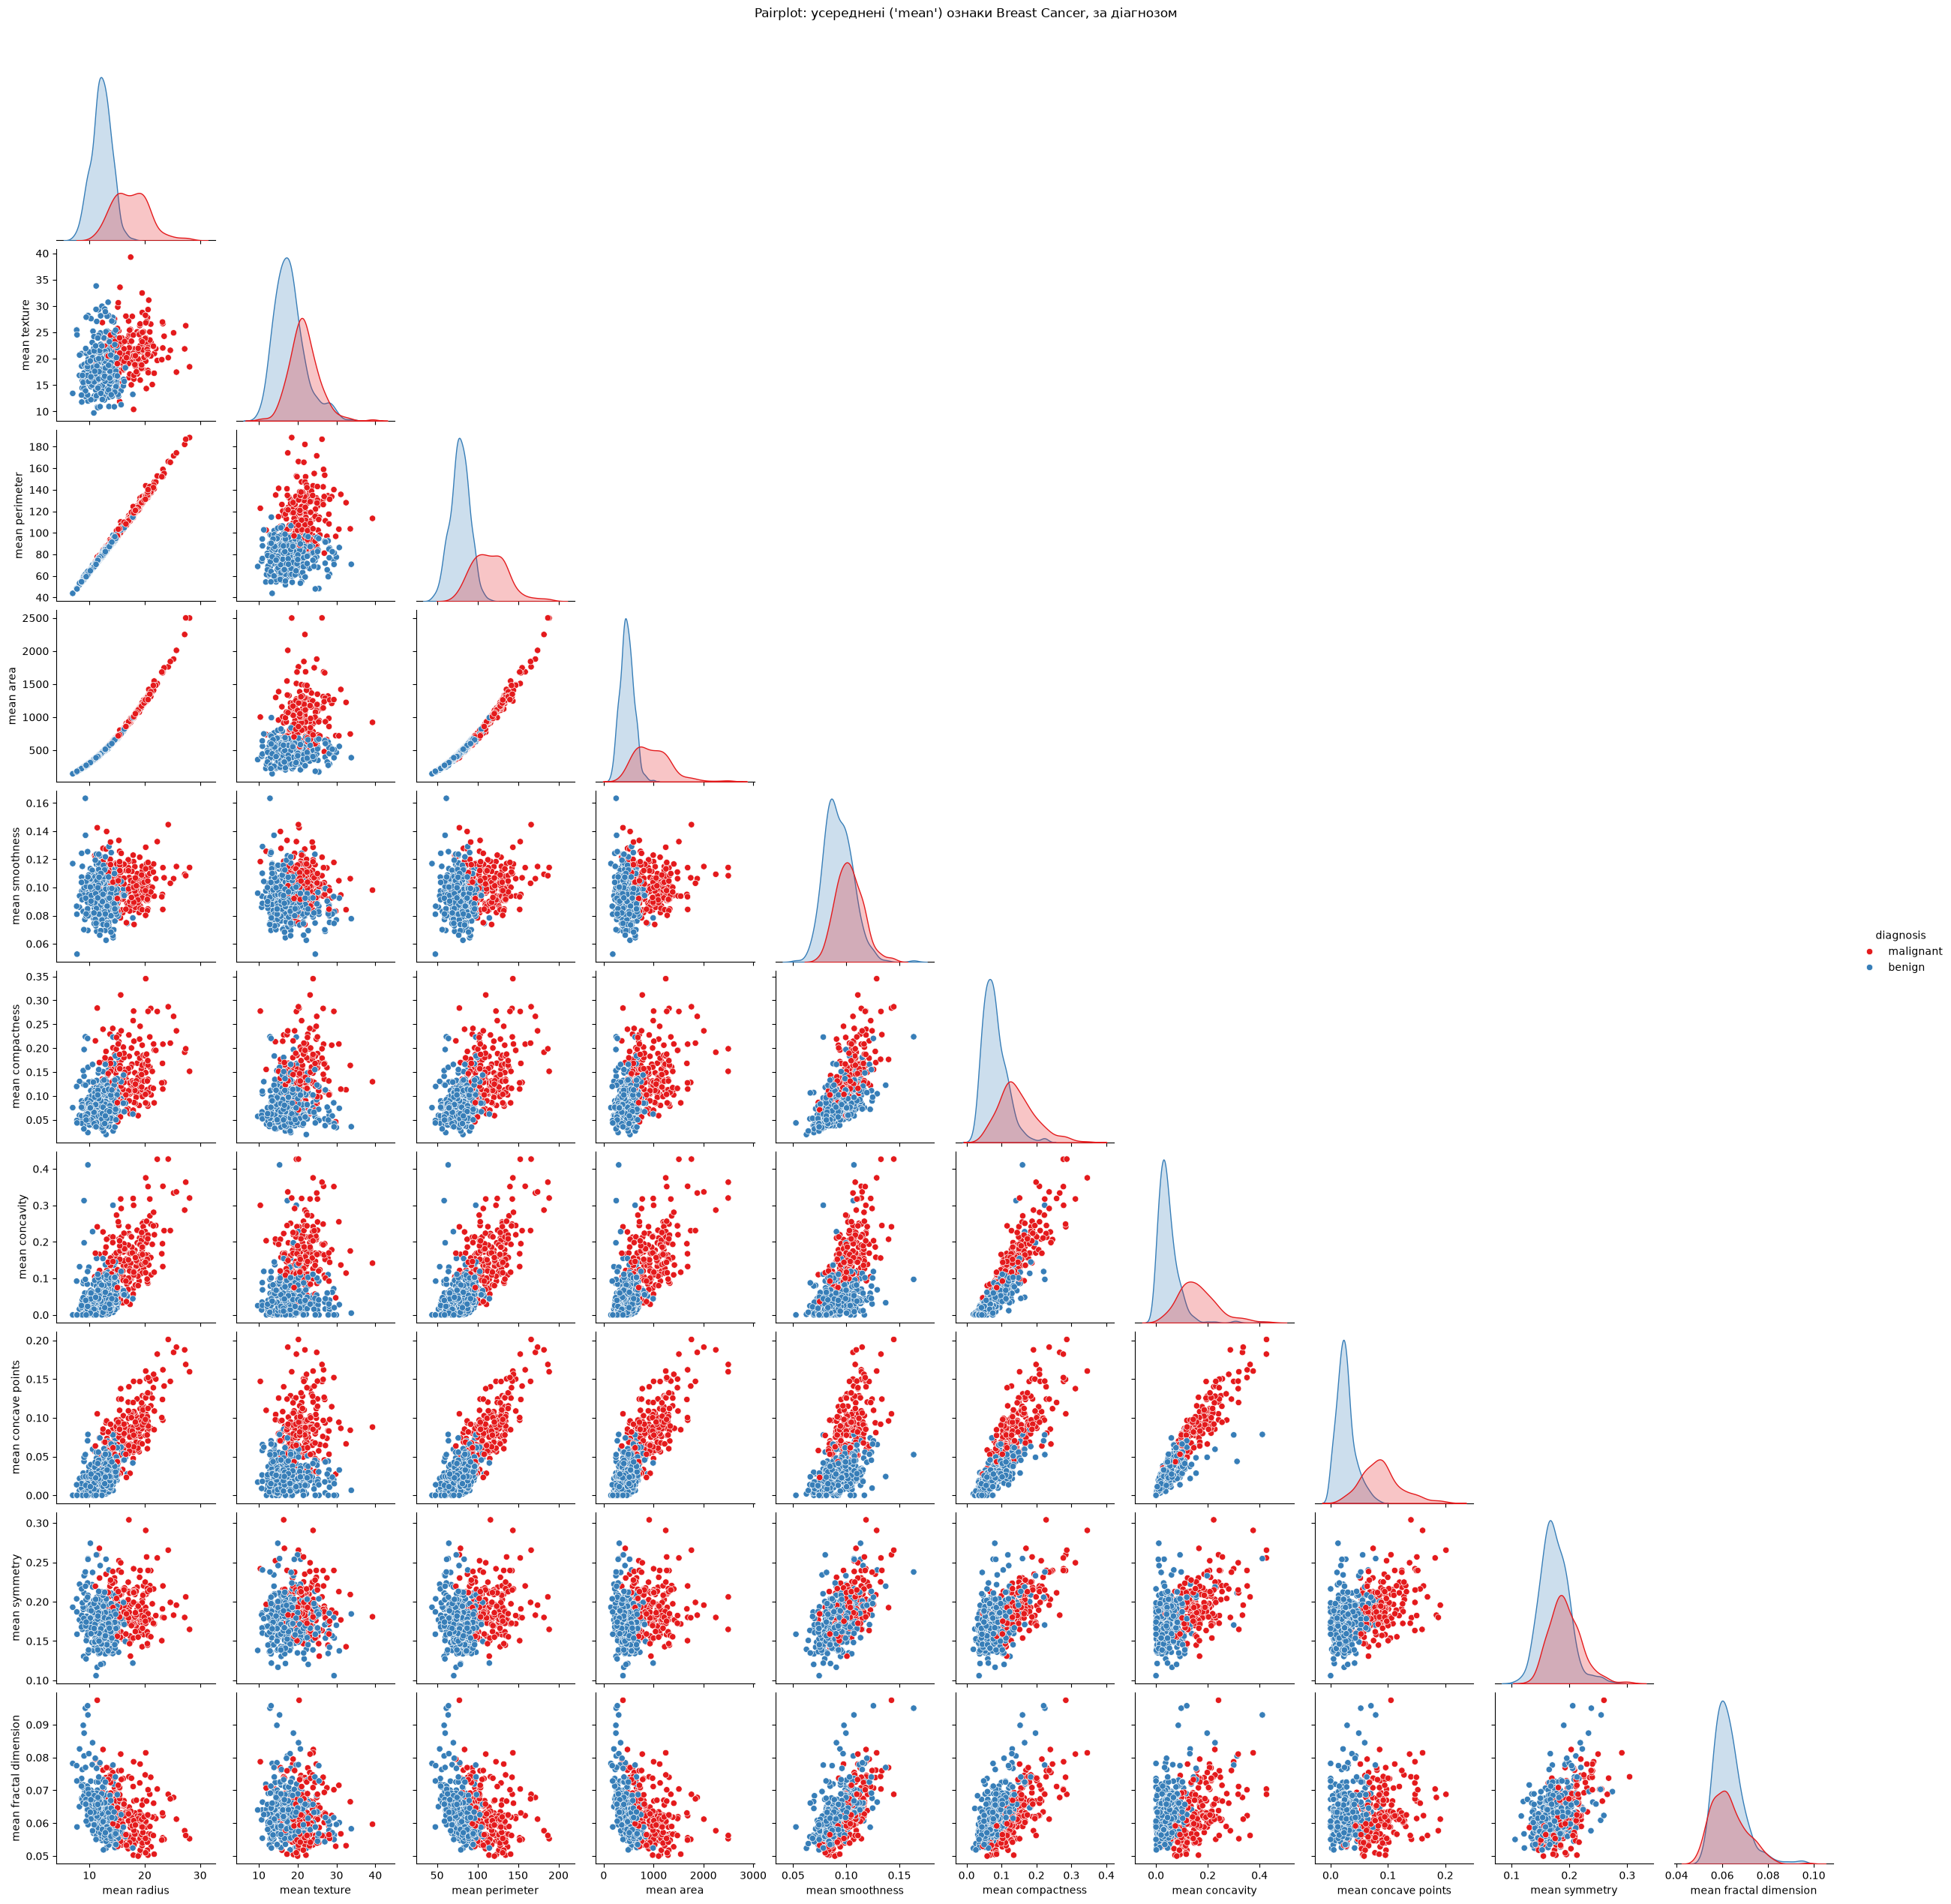

In [7]:
mean_cols = [c for c in feature_cols if c.startswith("mean ")]

sns.pairplot(bc_df[mean_cols + ["diagnosis"]], hue="diagnosis", palette="Set1", corner=True)
plt.suptitle("Pairplot: усереднені ('mean') ознаки Breast Cancer, за діагнозом", y=1.02)
plt.show()

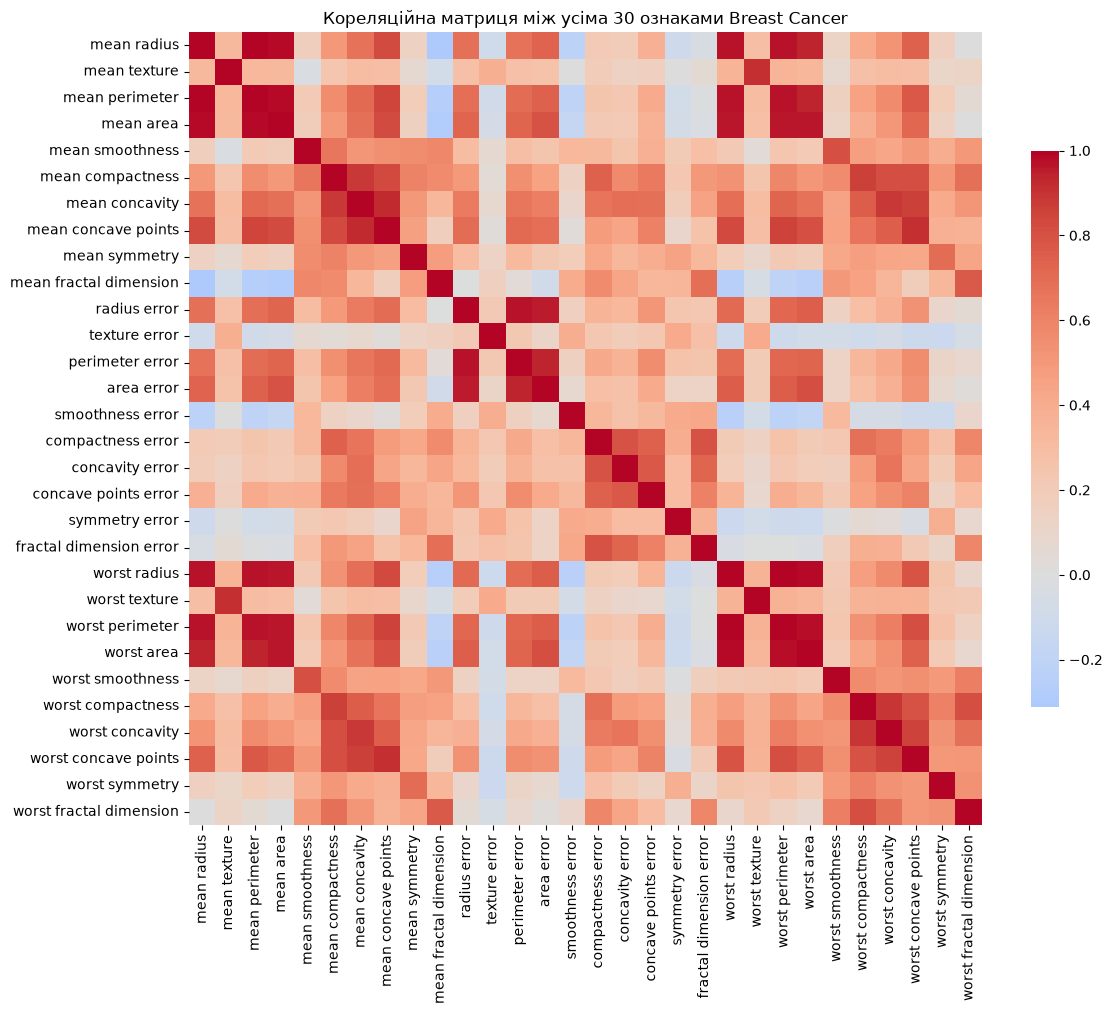

In [8]:
plt.figure(figsize=(12, 10))
sns.heatmap(bc_df[feature_cols].corr(), cmap="coolwarm", center=0, square=True,
            xticklabels=True, yticklabels=True, cbar_kws={"shrink": 0.7})
plt.title("Кореляційна матриця між усіма 30 ознаками Breast Cancer")
plt.tight_layout()
plt.show()

### 7. Обчислення матриць відстаней для різних метрик

In [9]:
dist_metrics = ["cityblock", "cosine", "euclidean", "l1", "manhattan"]
distance_matrices = {m: pairwise_distances(bc_scaled, metric=m) for m in dist_metrics}

for m in dist_metrics:
    print(f"{m:<10} shape = {distance_matrices[m].shape}")

print()
print("cityblock == manhattan (numerically):", np.allclose(distance_matrices["cityblock"], distance_matrices["manhattan"]))
print("cityblock == l1        (numerically):", np.allclose(distance_matrices["cityblock"], distance_matrices["l1"]))

cityblock  shape = (569, 569)
cosine     shape = (569, 569)
euclidean  shape = (569, 569)
l1         shape = (569, 569)
manhattan  shape = (569, 569)

cityblock == manhattan (numerically): True
cityblock == l1        (numerically): True


### 8. Візуалізація матриць відстаней

Щоб теплові карти було легше інтерпретувати, впорядкуємо зразки за діагнозом (спочатку malignant, потім benign) — тоді якщо метрика добре відділяє два класи, на карті буде видно виразну блочну структуру (2 контрастні квадрати на діагоналі і темніша область поза ними).

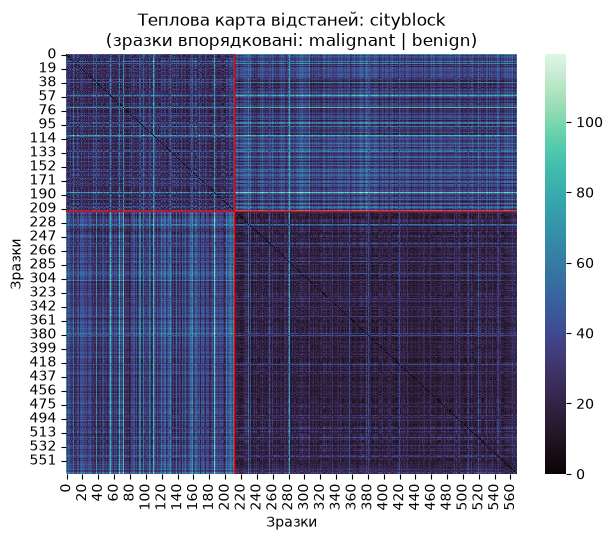

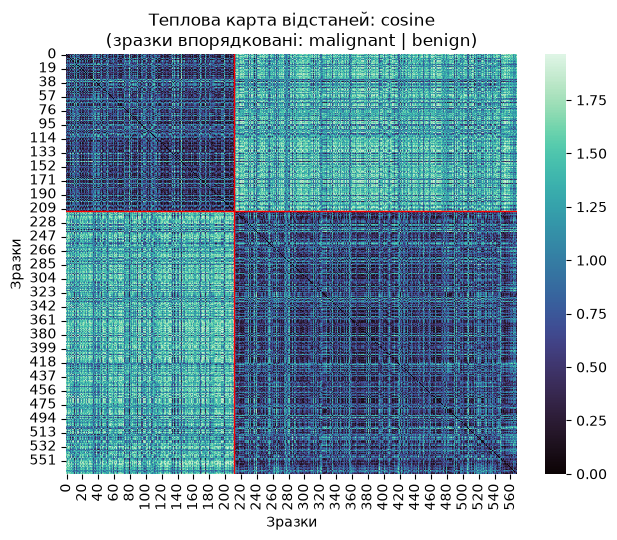

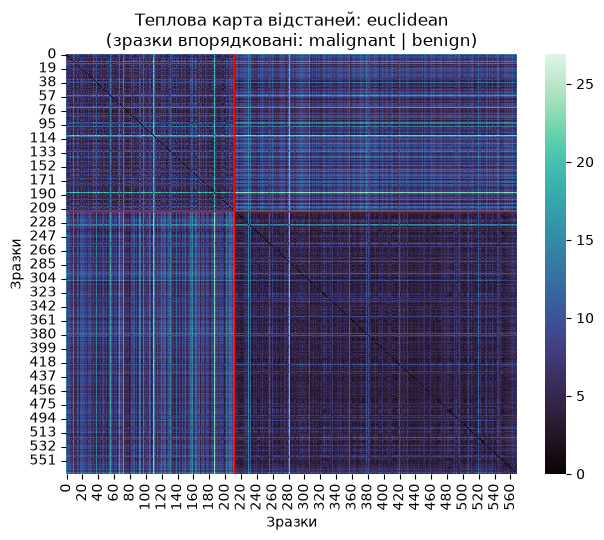

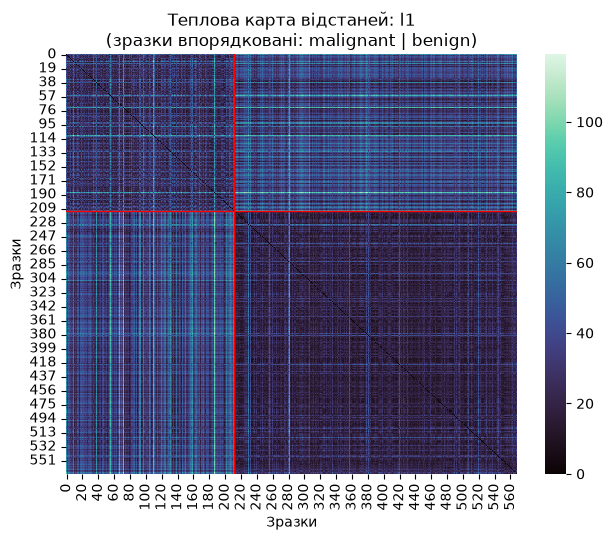

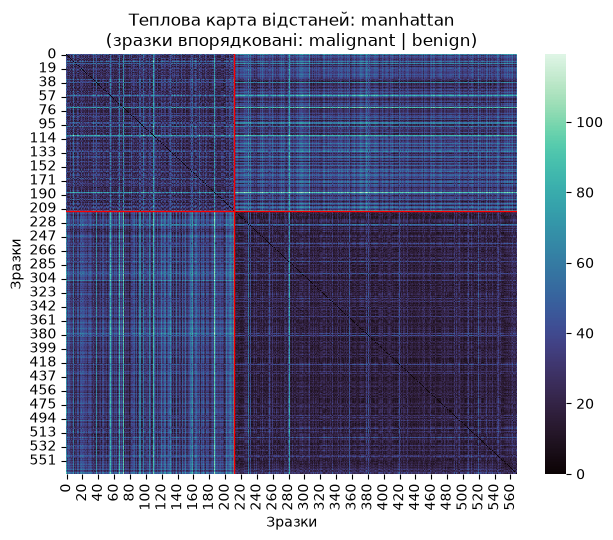

In [10]:
sort_idx = bc_df["target"].argsort(kind="stable").to_numpy()
bc_scaled_sorted = bc_scaled.iloc[sort_idx].reset_index(drop=True)
n_malignant = int((bc_df["target"] == 0).sum())

def plot_bc_distance_heatmap(metric):
    dist = pairwise_distances(bc_scaled_sorted, metric=metric)
    plt.figure(figsize=(6.5, 5.5))
    sns.heatmap(dist, cmap="mako")
    plt.axhline(n_malignant, color="red", linewidth=1)
    plt.axvline(n_malignant, color="red", linewidth=1)
    plt.title(f"Теплова карта відстаней: {metric}\n(зразки впорядковані: malignant | benign)")
    plt.xlabel("Зразки")
    plt.ylabel("Зразки")
    plt.tight_layout()
    plt.show()


for metric in dist_metrics:
    plot_bc_distance_heatmap(metric)

### 9. Кількісне порівняння ефективності метрик

Скористаємось тим самим підходом, що й у прикладі вище: агломеративна кластеризація на матриці попередньо обчислених відстаней (`metric='precomputed'`) з подальшим порівнянням отриманих кластерів із реальними діагнозами через `adjusted_rand_score` (ARI). Це дає об'єктивну кількісну міру того, наскільки добре кожна метрика відстані узгоджується зі справжньою структурою класів.

ARI для кожної метрики (Breast Cancer):
cityblock  ARI = 0.005
cosine     ARI = 0.780
euclidean  ARI = 0.007
l1         ARI = 0.005
manhattan  ARI = 0.005


C:\Users\iermo\AppData\Local\Temp\ipykernel_26912\2241123617.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(bc_ari_scores.keys()), y=list(bc_ari_scores.values()), palette="viridis")


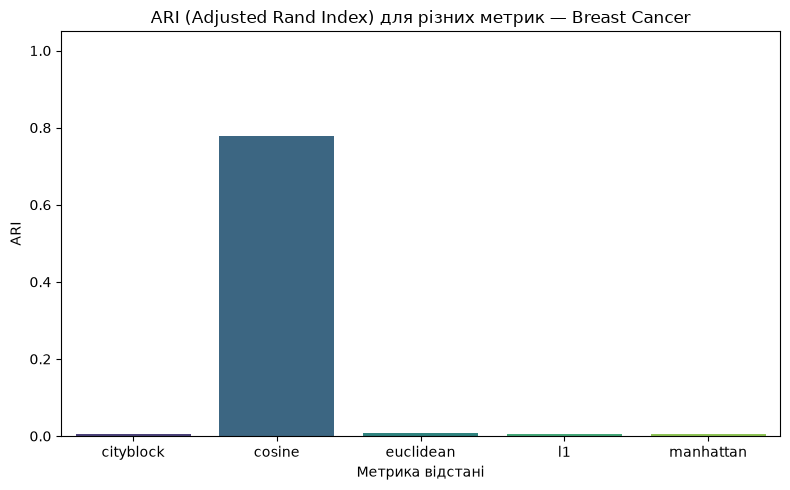

In [11]:
true_labels = bc_df["target"].values
bc_ari_scores = {}

print("ARI для кожної метрики (Breast Cancer):")
for metric in dist_metrics:
    dist = distance_matrices[metric]
    model = AgglomerativeClustering(n_clusters=2, metric="precomputed", linkage="average")
    pred_labels = model.fit_predict(dist)
    ari = adjusted_rand_score(true_labels, pred_labels)
    bc_ari_scores[metric] = ari
    print(f"{metric:<10} ARI = {ari:.3f}")

plt.figure(figsize=(8, 5))
sns.barplot(x=list(bc_ari_scores.keys()), y=list(bc_ari_scores.values()), palette="viridis")
plt.title("ARI (Adjusted Rand Index) для різних метрик — Breast Cancer")
plt.xlabel("Метрика відстані")
plt.ylabel("ARI")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

### Висновок

**cityblock, l1 і manhattan — це одна й та сама метрика.** Перевірка `np.allclose` підтвердила, що всі три дають числово ідентичні матриці відстаней — це не три різні способи виміряти відстань, а три імені для однієї метрики (L1 / Manhattan-відстань) у `sklearn.metrics.pairwise_distances`. Тобто з п'яти запропонованих у завданні метрик реально різних — лише три: **L1** (cityblock = l1 = manhattan), **euclidean** (L2) та **cosine**.

**Кількісне порівняння (ARI, агломеративна кластеризація):**

| Метрика | ARI |
|---|---|
| cosine    | **0.780** |
| euclidean | 0.007 |
| cityblock | 0.005 |
| l1        | 0.005 |
| manhattan | 0.005 |

Різниця разюча: `cosine` на порядки ефективніша за всі L1/L2-метрики для цього набору даних.

**Чому так сталося.** Розмір знайдених кластерів це пояснює напряму: при `linkage='average'` та L1/L2-метриках алгоритм на 30-вимірних стандартизованих даних Breast Cancer будує кластери розміру **567 проти 2** (cityblock/l1/manhattan) і **566 проти 3** (euclidean) — тобто фактично лише кілька зразків-"викидів" відокремлюються в один кластер, а решта 566-567 зразків (і malignant, і benign упереміш) потрапляють в інший. Це класичний ефект "ланцюгової" (chaining) поведінки average-linkage у поєднанні з L1/L2-відстанями у відносно високій розмірності: кластеризація підлаштовується під кілька найвіддаленіших точок, а не під реальну структуру класів. `cosine`, натомість, дав збалансований поділ **378 проти 191** — набагато ближчий до реального співвідношення класів (357 benign проти 212 malignant), і саме тому ARI тут на два порядки вищий.

**Чому cosine краще підходить саме тут.** Косинусна відстань вимірює відмінність у *напрямку* (пропорціях між ознаками), а не в *абсолютному положенні* точки у просторі. Для медичних вимірів клітин (радіус, периметр, площа тощо, які сильно корелюють між собою — див. теплову карту кореляції у кроці 6) саме співвідношення ознак одна до одної несе діагностичну інформацію, а не їхня конкретна величина в стандартизованих одиницях. Евклідова/L1-відстань більш чутлива до кількох зразків з екстремальними значеннями окремих ознак (пухлини з нетиповими розмірами), через що вони "перетягують" на себе всю структуру кластеризації.

**Практичний висновок.** Для цього набору даних (і, ймовірно, для подібних медичних/біологічних даних із сильно корельованими ознаками) `cosine` — явно найефективніша метрика відстані з-поміж перевірених для задачі кластеризації за діагнозом. Використання L1/L2-метрик тут вимагало б додаткової обробки (наприклад, зменшення розмірності через PCA перед кластеризацією, інший linkage — `ward` замість `average`, або видалення викидів), щоб отримати прийнятний результат. Це показує, що вибір метрики відстані — не формальність, а рішення, що напряму визначає, чи взагалі кластеризація зможе знайти змістовну структуру в даних.
